📊 Blocklängen:
  Block n=-1: 103 Samples, 2575.0 ms
  Block n=0: 103 Samples, 2575.0 ms
  Block n=1: 235 Samples, 5875.0 ms


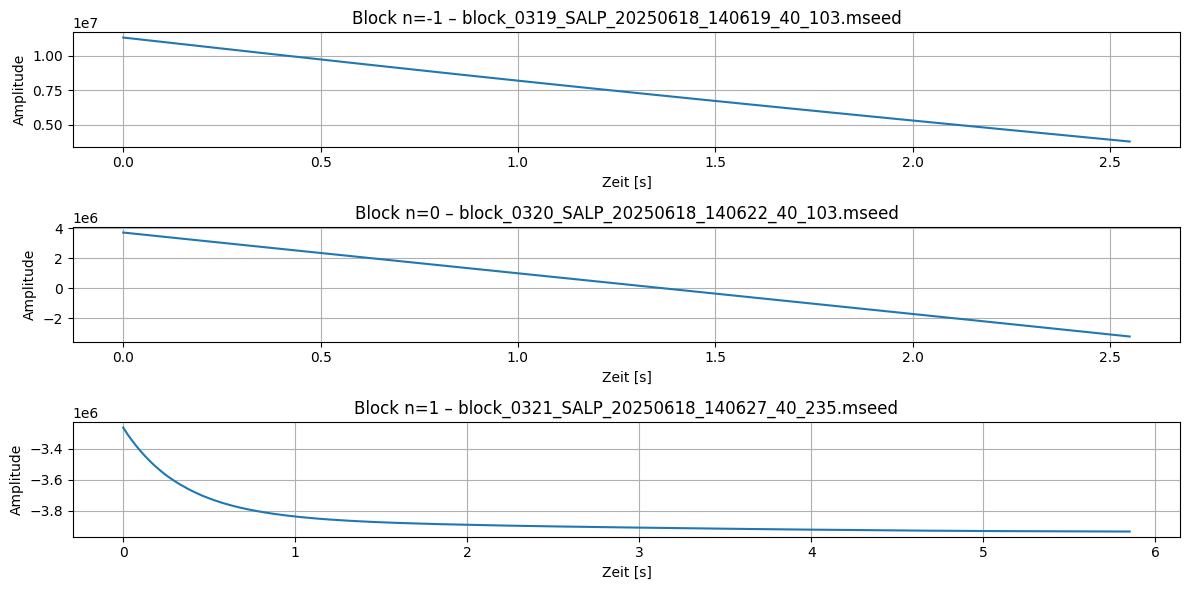

In [5]:
# Step 1

import obspy
import matplotlib.pyplot as plt

# 🔧 MSEED-Dateien im lokalen Ordner
mseed_files = [
    #"block_0003_20250523_112022.mseed",  # n = -1
    #"block_0004_20250523_112049.mseed",  # n =  0
    #"block_0005_20250523_112115.mseed"   # n = +1
    #"block_0313_SALP_20250618_140554_40_372.mseed",
   # "block_0314_SALP_20250618_140603_40_365.mseed",
   # "block_0315_SALP_20250618_140608_40_210.mseed",
   # "block_0316_SALP_20250618_140611_40_103.mseed"
    
    "block_0319_SALP_20250618_140619_40_103.mseed",
    "block_0320_SALP_20250618_140622_40_103.mseed",
    "block_0321_SALP_20250618_140627_40_235.mseed"
]

# 📥 Lade die drei Blöcke
traces = [obspy.read(f)[0] for f in mseed_files]

# 🖨️ Länge der Blöcke ausgeben
print("📊 Blocklängen:")
for i, tr in enumerate(traces):
    samples = len(tr.data)
    duration_ms = samples / tr.stats.sampling_rate * 1000
    print(f"  Block n={i - 1}: {samples} Samples, {duration_ms:.1f} ms")

# 📈 Plotten
plt.figure(figsize=(12, 6))
for i, tr in enumerate(traces):
    plt.subplot(3, 1, i + 1)
    plt.plot(tr.times(), tr.data)
    plt.title(f"Block n={i - 1} – {mseed_files[i]}")
    plt.xlabel("Zeit [s]")
    plt.ylabel("Amplitude")
    plt.grid(True)

plt.tight_layout()
plt.show()


📏 Verwende x = 1000 ms → 40 Samples bei 40.0 Hz
🧱 Mega-Block erstellt:
  Länge: 183 Samples
  Dauer: 4.58 Sekunden


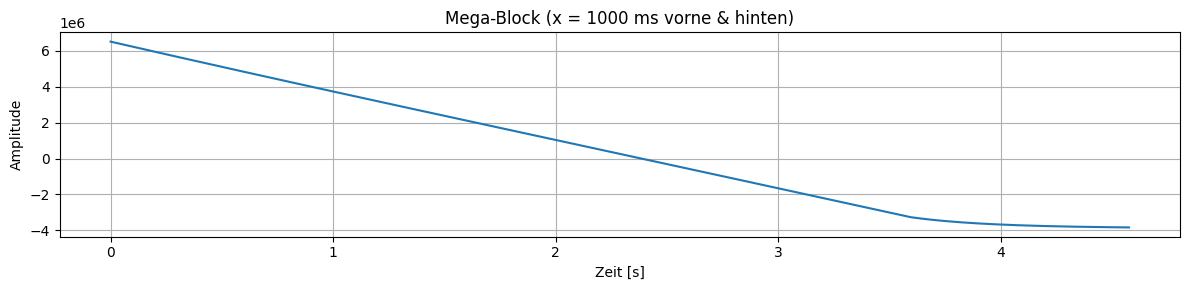

In [6]:
# Step 2

import numpy as np
import matplotlib.pyplot as plt

# 🔧 Dauer x in Millisekunden für die Ränder
x_ms = 1000  # Beispiel: 100 Millisekunden

# Traces aus Schritt 1
trace_prev = traces[0]  # n = -1
trace_main = traces[1]  # n =  0
trace_next = traces[2]  # n = +1

# Samplerate
sr = trace_main.stats.sampling_rate
samples_x = int((x_ms / 1000) * sr)

print(f"📏 Verwende x = {x_ms} ms → {samples_x} Samples bei {sr} Hz")

# 🧩 Ränder & Mitte extrahieren
segment_prev = trace_prev.data[-samples_x:]
segment_main = trace_main.data
segment_next = trace_next.data[:samples_x]

# 🔗 Mega-Block zusammensetzen
mega_block = np.concatenate([segment_prev, segment_main, segment_next])

print(f"🧱 Mega-Block erstellt:")
print(f"  Länge: {len(mega_block)} Samples")
print(f"  Dauer: {len(mega_block)/sr:.2f} Sekunden")

time_axis = np.linspace(0, len(mega_block)/sr, num=len(mega_block))

plt.figure(figsize=(12, 3))
plt.plot(time_axis, mega_block)
plt.title(f"Mega-Block (x = {x_ms} ms vorne & hinten)")
plt.xlabel("Zeit [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()



🎚️ Resampling:
  Originalrate: 40.0 Hz
  Zielrate: 44100 Hz
  Länge vorher: 183 Samples = 4575.00 ms
  Länge nachher: 201757 Samples = 4574.99 ms


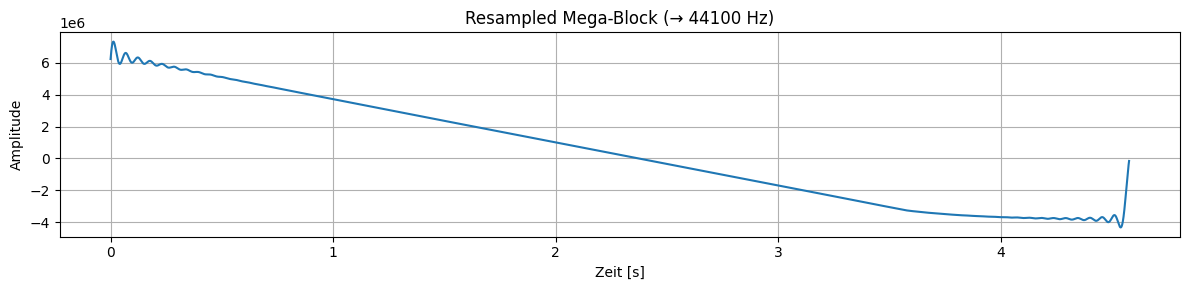

In [7]:
# Step 3

import resampy
import numpy as np
import matplotlib.pyplot as plt

# 🔧 Ziel-Samplerate
target_sr = 44100

# 🖨️ Info vor dem Resampling
orig_samples = len(mega_block)
orig_sr = sr  # aus vorherigem Schritt
orig_duration_ms = orig_samples / orig_sr * 1000

print("🎚️ Resampling:")
print(f"  Originalrate: {orig_sr} Hz")
print(f"  Zielrate: {target_sr} Hz")
print(f"  Länge vorher: {orig_samples} Samples = {orig_duration_ms:.2f} ms")

# 📈 Resample mit resampy
mega_block_resampled = resampy.resample(mega_block, sr_orig=orig_sr, sr_new=target_sr)

# 🖨️ Info nach dem Resampling
resampled_samples = len(mega_block_resampled)
resampled_duration_ms = resampled_samples / target_sr * 1000

print(f"  Länge nachher: {resampled_samples} Samples = {resampled_duration_ms:.2f} ms")

# 📊 Plot
time_resampled = np.linspace(0, resampled_duration_ms / 1000, num=resampled_samples)

plt.figure(figsize=(12, 3))
plt.plot(time_resampled, mega_block_resampled)
plt.title(f"Resampled Mega-Block (→ {target_sr} Hz)")
plt.xlabel("Zeit [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()


🔊 Hochpassfilter:
  Grenzfrequenz: 1 Hz
  Ordnung: 1
  Vor dem Filter: 201757 Samples = 4574.99 ms
  Nach dem Filter: 201757 Samples = 4574.99 ms


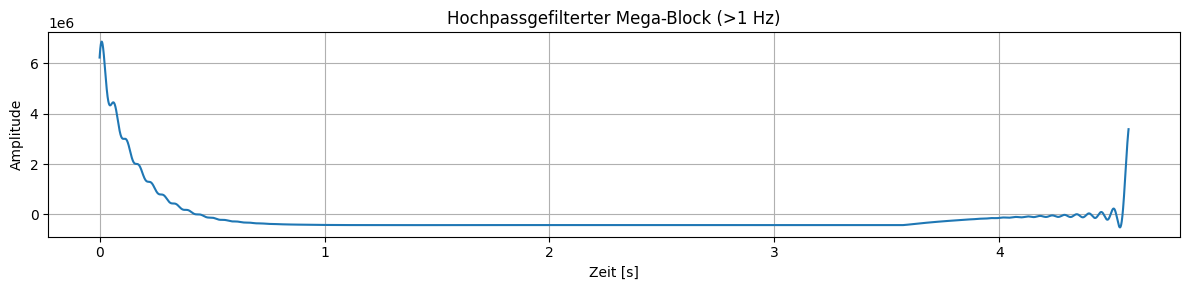

In [8]:
# Step 4

from scipy.signal import butter, lfilter

# 🔧 Filterparameter
cutoff = 1  # Hz
order = 1     # Filterordnung

def butter_highpass(data, cutoff, fs, order=4):
    nyq = 0.5 * fs
    norm_cutoff = cutoff / nyq
    b, a = butter(order, norm_cutoff, btype='high', analog=False)
    return lfilter(b, a, data)

# 🧠 Info vor dem Filtern
samples_before = len(mega_block_resampled)
duration_before = samples_before / target_sr * 1000

print("🔊 Hochpassfilter:")
print(f"  Grenzfrequenz: {cutoff} Hz")
print(f"  Ordnung: {order}")
print(f"  Vor dem Filter: {samples_before} Samples = {duration_before:.2f} ms")

# 📈 Filter anwenden
mega_block_resampled_filtered = butter_highpass(mega_block_resampled, cutoff, fs=target_sr, order=order)

# 🧠 Info nach dem Filtern (ändert sich nicht in Länge)
samples_after = len(mega_block_resampled_filtered)
duration_after = samples_after / target_sr * 1000
print(f"  Nach dem Filter: {samples_after} Samples = {duration_after:.2f} ms")

# 📊 Plot
time_filtered = np.linspace(0, duration_after / 1000, num=samples_after)

plt.figure(figsize=(12, 3))
plt.plot(time_filtered, mega_block_resampled_filtered)
plt.title(f"Hochpassgefilterter Mega-Block (>{cutoff} Hz)")
plt.xlabel("Zeit [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()


✂️ Zuschneiden des Mega-Blocks:
  Entfernt: 990 ms vorne und hinten → 43659 Samples je Seite
  Ergebnis: 114439 Samples = 2594.99 ms
  Ursprüngliche Blockdauer: 2575.00 ms
  Resultierende Länge: Original + 2y = 2594.99 ms


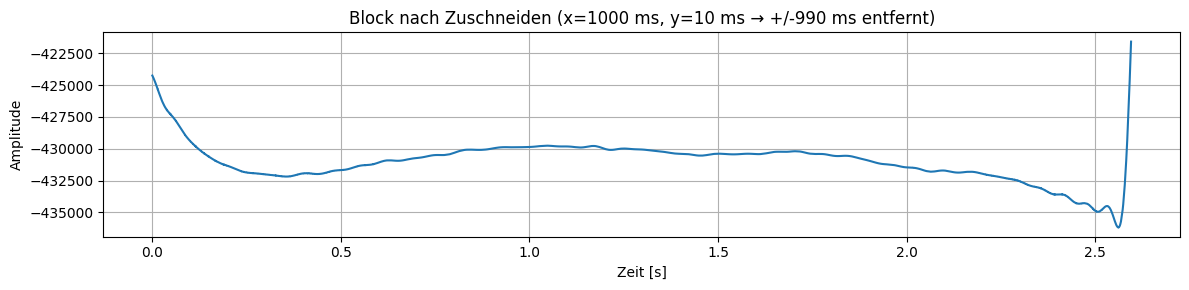

In [9]:
# Step 5

# 🔧 Parameter
x_ms = 1000  # vorher festgelegt beim Mega-Block-Zusammenbau
y_ms = 10   # neue Angabe für Crossfade

# ✂️ Anzahl Samples, die vorne und hinten abgeschnitten werden
cut_ms = x_ms - y_ms
cut_samples = int(cut_ms / 1000 * target_sr)

total_len = len(mega_block_resampled_filtered)
start = cut_samples
end = total_len - cut_samples

# ⚠️ Sicherheit: nicht zu kurz schneiden
if end <= start:
    raise ValueError(f"Block zu kurz zum Zuschneiden: {total_len} Samples, cut = {cut_samples} vorne + hinten")

# ✂️ Zuschneiden
block_processed = mega_block_resampled_filtered[start:end]

# 🖨️ Info
new_len = len(block_processed)
new_dur_ms = new_len / target_sr * 1000

print("✂️ Zuschneiden des Mega-Blocks:")
print(f"  Entfernt: {cut_ms} ms vorne und hinten → {cut_samples} Samples je Seite")
print(f"  Ergebnis: {new_len} Samples = {new_dur_ms:.2f} ms")
print(f"  Ursprüngliche Blockdauer: {len(trace_main.data)/sr*1000:.2f} ms")
print(f"  Resultierende Länge: Original + 2y = {new_dur_ms:.2f} ms")

# 📈 Plot
time_trimmed = np.linspace(0, new_dur_ms / 1000, num=new_len)

plt.figure(figsize=(12, 3))
plt.plot(time_trimmed, block_processed)
plt.title(f"Block nach Zuschneiden (x={x_ms} ms, y={y_ms} ms → +/-{cut_ms} ms entfernt)")
plt.xlabel("Zeit [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()


💾 WAV gespeichert als: block_0004_processed.wav

📊 WAV-Daten:
  Samplerate: 44100 Hz
  Samples:    114439
  Dauer:      2594.99 ms
  Peak-Level: 1.000


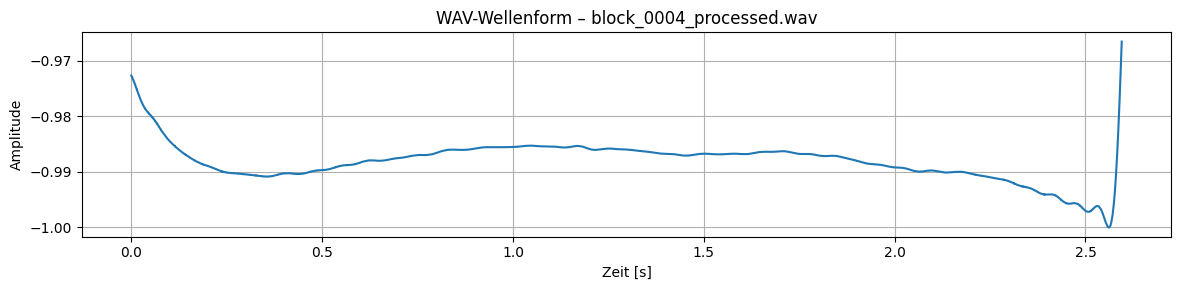

In [10]:
# Schritt 6

import soundfile as sf
import matplotlib.pyplot as plt
import numpy as np

# 🔧 Optional: Normalisieren
block_normalized = block_processed / np.max(np.abs(block_processed))

# 🔧 WAV-Dateiname
wav_filename = "block_0004_processed.wav"

# 💾 Speichern
sf.write(wav_filename, block_normalized, samplerate=target_sr)
print(f"💾 WAV gespeichert als: {wav_filename}")

# 📊 Infos ausgeben
samples = len(block_normalized)
duration_ms = samples / target_sr * 1000
peak = np.max(np.abs(block_normalized))

print("\n📊 WAV-Daten:")
print(f"  Samplerate: {target_sr} Hz")
print(f"  Samples:    {samples}")
print(f"  Dauer:      {duration_ms:.2f} ms")
print(f"  Peak-Level: {peak:.3f}")

# 📈 Plot der Wellenform
time_axis = np.linspace(0, duration_ms / 1000, num=samples)

plt.figure(figsize=(12, 3))
plt.plot(time_axis, block_normalized)
plt.title(f"WAV-Wellenform – {wav_filename}")
plt.xlabel("Zeit [s]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()
